# Building a Mini GPT from Scratch

**Name:** Ritika Mukesh Neema

**SID:** 019306638

**SEED:** 6638

This notebook builds a decoder-only, GPT-style Transformer entirely from
`torch.nn` primitives (`nn.Linear`, `nn.LayerNorm`, `nn.GELU`) — no
`nn.Transformer`, no `nn.MultiheadAttention`, no HuggingFace model classes.

It extends the course demo (*single-head attention, one decoder block,
greedy decoding only*) into:

- **Multi-head** masked self-attention (4 heads), implemented manually
- A **stack of decoder blocks** (4 blocks) instead of one
- **Temperature sampling** and **top-k sampling**, compared against greedy decoding

The model is trained at the character level on `Shakespeare.txt` — the
Romeo & Juliet balcony-scene excerpt provided with the assignment.


In [1]:
import math
import time
import json

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

SEED = 6638  # derived from student ID 019306638

def set_seed(seed=SEED):
    torch.manual_seed(seed)

set_seed(SEED)


Device: cpu


## Part 1 — Data Preparation

### 1.1 Character-Level Tokenization

We read `Shakespeare.txt`, extract the set of unique characters, and build
two lookup tables: `char_to_idx` (character → integer id) and `idx_to_char`
(integer id → character). `encode`/`decode` convert between raw text and
token-id sequences.

In [2]:
with open("Shakespeare.txt", "r", encoding="utf-8") as f:
    text = f.read()

chars = sorted(list(set(text)))
vocab_size = len(chars)

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

def encode(s):
    return [char_to_idx[c] for c in s]

def decode(ids):
    return "".join(idx_to_char[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)

print("Total characters:", len(text))
print("Vocabulary size:", vocab_size)
print("Vocabulary:", "".join(chars))


Total characters: 1738
Vocabulary size: 49
Vocabulary: 
 !,.:;?ABCDEHIJLMNORSTUWabcdefghiklmnoprstuvwyz’


### 1.2 Sliding Window Dataset

With sequence length `128`, each training example is a window of 128
consecutive tokens as input and the same window shifted one character to
the right as the target:

```
input:  tokens[t : t+128]
target: tokens[t+1 : t+129]
```

This is the standard next-character-prediction setup for autoregressive
language modeling — every position in the window supplies a
"given-the-past, predict-the-next-character" training signal.

In [3]:
class SlidingWindowCharDataset(Dataset):
    def __init__(self, data_tensor, block_size):
        self.data = data_tensor
        self.block_size = block_size

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        x = self.data[idx: idx + self.block_size]
        y = self.data[idx + 1: idx + self.block_size + 1]
        return x, y

BLOCK_SIZE = 128
train_dataset = SlidingWindowCharDataset(data, BLOCK_SIZE)
print("Number of sliding-window training pairs:", len(train_dataset))


Number of sliding-window training pairs: 1610


In [4]:
# Show 2 example input-target pairs, decoded back to text
for i in [0, 1]:
    x, y = train_dataset[i]
    print(f"--- Example {i} ---")
    print("input :", repr(decode(x.tolist())))
    print("target:", repr(decode(y.tolist())))
    print()


--- Example 0 ---
input : 'ROMEO:\nBut, soft! what light through yonder window breaks?\nIt is the east, and Juliet is the sun.\nArise, fair sun, and kill the '
target: 'OMEO:\nBut, soft! what light through yonder window breaks?\nIt is the east, and Juliet is the sun.\nArise, fair sun, and kill the e'

--- Example 1 ---
input : 'OMEO:\nBut, soft! what light through yonder window breaks?\nIt is the east, and Juliet is the sun.\nArise, fair sun, and kill the e'
target: 'MEO:\nBut, soft! what light through yonder window breaks?\nIt is the east, and Juliet is the sun.\nArise, fair sun, and kill the en'



## Part 2 — GPT Architecture

### From the demo's single-head attention...

The course demo implements a single attention head with no explicit head
splitting:

```python
class SingleHeadSelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, C = x.shape
        Q, K, V = self.q(x), self.k(x), self.v(x)
        scores = Q @ K.transpose(-2, -1) / math.sqrt(C)
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float('-inf'))
        attn = F.softmax(scores, dim=-1)
        return attn @ V
```

This lets every position attend to earlier positions, but only in a
**single** representation subspace — the whole `d_model` dimension is used
for one attention pattern.

### ...to manual multi-head masked self-attention

Multi-head attention splits `d_model` into `n_head` smaller subspaces
(`d_head = d_model / n_head`), computes scaled dot-product attention
independently in each subspace, and then concatenates the results back
together. Each head can specialize — e.g. one head might track punctuation
boundaries, another nearby characters, another repeated substrings.

Steps implemented below:
1. Project `x` to `Q`, `K`, `V` with one linear layer each (`d_model → d_model`)
2. Reshape each into `[B, n_head, T, d_head]`
3. Compute attention scores `QKᵀ / sqrt(d_head)` per head → `[B, n_head, T, T]`
4. Apply a causal mask so position `t` cannot see positions `> t`
5. Softmax → attention weights, then weighted sum of `V`
6. Merge heads back to `[B, T, d_model]` and apply an output projection

No `nn.MultiheadAttention` is used anywhere — every step is explicit
tensor math.

In [5]:
class SingleHeadSelfAttention(nn.Module):
    """Course-demo baseline, kept here only as a reference point for the
    multi-head extension below (not used in the final model)."""
    def __init__(self, d_model):
        super().__init__()
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, C = x.shape
        Q, K, V = self.q(x), self.k(x), self.v(x)
        scores = Q @ K.transpose(-2, -1) / math.sqrt(C)
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float("-inf"))
        attn = F.softmax(scores, dim=-1)
        return attn @ V


class MultiHeadSelfAttention(nn.Module):
    """Manual multi-head masked (causal) self-attention. Q/K/V projections
    and the attention math are implemented explicitly — no
    nn.MultiheadAttention."""

    def __init__(self, d_model, n_head, block_size, dropout=0.1):
        super().__init__()
        assert d_model % n_head == 0, "d_model must be divisible by n_head"
        self.n_head = n_head
        self.d_head = d_model // n_head

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

        mask = torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size)
        self.register_buffer("causal_mask", mask)

    def forward(self, x):
        B, T, C = x.shape

        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        # split into heads: (B, T, C) -> (B, n_head, T, d_head)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)

        # scaled dot-product attention, per head
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(self.d_head))
        att = att.masked_fill(self.causal_mask[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)

        out = att @ v                                      # (B, n_head, T, d_head)
        out = out.transpose(1, 2).contiguous().view(B, T, C)  # merge heads
        out = self.resid_dropout(self.out_proj(out))
        return out


In [6]:
# Sanity check: causal masking + output shape
torch.manual_seed(0)
test_attn = MultiHeadSelfAttention(d_model=16, n_head=4, block_size=8)
test_x = torch.randn(2, 8, 16)
test_out = test_attn(test_x)
print("Input shape :", test_x.shape)
print("Output shape:", test_out.shape)

# Verify the mask is strictly lower-triangular (causal)
print("Causal mask (1 = attendable):")
print(test_attn.causal_mask[0, 0].int())


Input shape : torch.Size([2, 8, 16])
Output shape: torch.Size([2, 8, 16])
Causal mask (1 = attendable):
tensor([[1, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1, 1, 1]], dtype=torch.int32)


### Transformer Decoder Block

Each block wraps multi-head attention and a feed-forward network in
residual connections with pre-LayerNorm:

```
x = x + MultiHeadAttention(LayerNorm(x))
x = x + FeedForward(LayerNorm(x))
```

- **Residual connections** let gradients flow directly through the network,
  which is what makes stacking multiple blocks trainable.
- **LayerNorm** stabilizes activations before each sub-layer.
- **Feed-forward network** (`Linear → GELU → Linear`) refines each token's
  representation independently, expanding to `4 × d_model` and back.

In [7]:
class FeedForward(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_head, block_size, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x


### The full GPT model

`MiniGPT` combines:

- **Token embedding** — maps character ids to `d_model`-dim vectors
- **Learnable positional embedding** — one learned vector per position
  (0…`block_size-1`), added to the token embedding
- A **stack of decoder blocks** (≥ 2 — we use 4)
- A final **LayerNorm** and **linear projection** to vocabulary logits

`generate()` implements all three decoding strategies used in Part 4.

In [8]:
class MiniGPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_head, n_layer, block_size, dropout=0.1):
        super().__init__()
        self.block_size = block_size
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(block_size, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList(
            [DecoderBlock(d_model, n_head, block_size, dropout) for _ in range(n_layer)]
        )
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

        self.n_head = n_head
        self.n_layer = n_layer
        self.d_model = d_model

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.block_size, "sequence longer than block_size"

        tok_emb = self.token_emb(idx)
        pos = torch.arange(T, device=idx.device)
        pos_emb = self.pos_emb(pos)[None, :, :]
        x = self.drop(tok_emb + pos_emb)

        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, mode="greedy", temperature=1.0, top_k=None):
        """mode: 'greedy' | 'temperature' | 'top_k'"""
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]

            if mode == "greedy":
                next_id = torch.argmax(logits, dim=-1, keepdim=True)
            else:
                logits = logits / max(temperature, 1e-8)
                if mode == "top_k" and top_k is not None:
                    v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                    logits[logits < v[:, [-1]]] = float("-inf")
                probs = F.softmax(logits, dim=-1)
                next_id = torch.multinomial(probs, num_samples=1)

            idx = torch.cat([idx, next_id], dim=1)
        self.train()
        return idx


In [9]:
D_MODEL = 128
N_HEAD = 4
N_LAYER = 4

set_seed(SEED)
model = MiniGPT(vocab_size, D_MODEL, N_HEAD, N_LAYER, BLOCK_SIZE).to(device)
n_params = sum(p.numel() for p in model.parameters())

print("Total parameter count:", f"{n_params:,}")
print("Hidden dimension (d_model):", D_MODEL)
print("Number of heads:", N_HEAD)
print("Number of layers:", N_LAYER)


Total parameter count: 822,272
Hidden dimension (d_model): 128
Number of heads: 4
Number of layers: 4


## Part 3 — Training

Optimizer: **Adam**. Because `Shakespeare.txt` is a single short scene
(under 2,000 characters), we use a small batch size (16) so each epoch
still covers many overlapping windows, and train for 8 epochs — enough for
the loss to visibly and smoothly decrease.

In [10]:
BATCH_SIZE = 16
LR = 3e-4
EPOCHS = 8

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
print("Batches per epoch:", len(loader))

losses = []
t_start = time.time()
for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    losses.append(avg_loss)
    print(f"epoch {epoch:>2}/{EPOCHS} | loss {avg_loss:.4f}")

print(f"\nTotal training time: {time.time() - t_start:.1f}s")


Batches per epoch: 101


epoch  1/8 | loss 2.6914


epoch  2/8 | loss 2.1881


epoch  3/8 | loss 1.9077


epoch  4/8 | loss 1.5560


epoch  5/8 | loss 1.1090


epoch  6/8 | loss 0.7331


epoch  7/8 | loss 0.4961


epoch  8/8 | loss 0.3666

Total training time: 126.4s


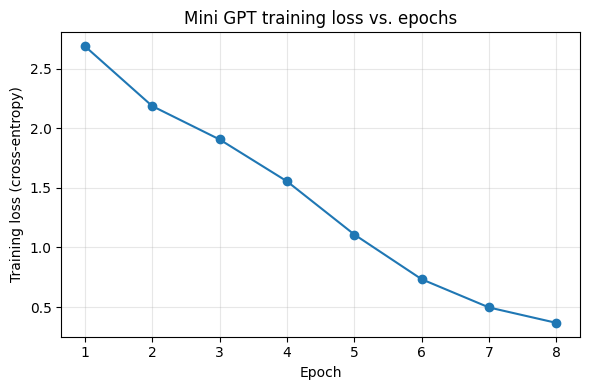

In [11]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, EPOCHS + 1), losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss (cross-entropy)")
plt.title("Mini GPT training loss vs. epochs")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Part 4 — Sampling

All three strategies below decode from the same prompt, **"ROMEO:"**, for
300 new characters, using the same random seed where randomness is
involved, so differences in output are due to the decoding strategy alone.

### 1. Greedy decoding
Always picks `argmax` of the next-character distribution. Deterministic —
the same model and prompt always produce the same continuation.

In [12]:
prompt = "ROMEO:"
prompt_ids = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
N_NEW_TOKENS = 300

set_seed(SEED)
greedy_out = model.generate(prompt_ids.clone(), N_NEW_TOKENS, mode="greedy")
greedy_text = decode(greedy_out[0].tolist())
print(greedy_text)


ROMEO:
By ame
I know not how to tell thee who I am:
My name, dear saint, is hateful to myself,
Because it is an enemy to thee;
Had I itt writtten, I’ll a nem the word Ill be ne Romeoreo.

JULIET:
What man art thou that thus bescreen’d in night
So stumblest oon my counsel?


ROMEO:
By a name
I knot how to 


### 2. Temperature sampling

Before softmax, logits are divided by a temperature `T`:

- `T < 1` sharpens the distribution → more confident, more repetitive, closer to greedy
- `T = 1` uses the model's raw distribution
- `T > 1` flattens the distribution → more randomness, more diverse, more errors

We compare three clearly different temperatures: **0.5, 1.0, 1.5**.

In [13]:
temperature_outputs = {}
for temp in [0.5, 1.0, 1.5]:
    set_seed(SEED)
    out = model.generate(prompt_ids.clone(), N_NEW_TOKENS, mode="temperature", temperature=temp)
    temperature_outputs[temp] = decode(out[0].tolist())
    print(f"----- temperature = {temp} -----")
    print(temperature_outputs[temp])
    print()


----- temperature = 0.5 -----
ROMEO:
By ame that thu thus namyself, though not a Montague.
What’s Montague? is it nor hand, nor foot,
Nor arm, nor face, nor any other part
Belonging to a man.
O be some other name!
What’s in a name? that which we call a rose
By any other word would smell as sweet;
So Romeo would, were he not Romeo call



----- temperature = 1.0 -----
ROMEO:
By ame thatll thu though not dont amee.
Rameo, defor thar nor fothame an which is no part of thee
By namy;
Or, if thou not pamy d O, isher willl are is n.

IET:
I amis amy amy ene
Thou at thy word woulld, sme she not wo bould,
ner Retake d wit;
Call non bet be ff.

ROMEO:
Ar, athat kis nor he.
Ar m



----- temperature = 1.5 -----
ROMEO:I nake thow toe d:
Call me I but love, and I’ll be new baptized;
Henceforth I nevever !
Be!
AnN;
And I’lltha be armne whice nos,
dor nonJut be mootNo whers!
Whatll ny Deiseny thor fa MEapart art Mond,
OumartWLI’s in ll mad nw nothe be
Sout fittoo.
Romeo, doff t thy name;
’t I is namy Whou Caland pul



### 3. Top-k sampling

Only the `k` highest-probability next characters are kept; the rest are
masked to zero probability before sampling. With a character-level
vocabulary of under 50 symbols, `k=5` restricts sampling to a small
shortlist (close to greedy/low-temperature behavior), while `k=20`
allows roughly 40% of the vocabulary through (much more diverse).

In [14]:
topk_outputs = {}
for k in [5, 20]:
    set_seed(SEED)
    out = model.generate(prompt_ids.clone(), N_NEW_TOKENS, mode="top_k", temperature=1.0, top_k=k)
    topk_outputs[k] = decode(out[0].tolist())
    print(f"----- top_k = {k} -----")
    print(topk_outputs[k])
    print()


----- top_k = 5 -----
ROMEO:
By ame thatll thu though not a Montague.
What’s Montague? is itor nor hand, nor foot,
Nor arm, nor face, nother any other part
Belonging to ma man.
O be some other name!
What’s in a name? that which we call a rose
By any other word would smell Roveas sweet;
So Romeo would, were he not Romeo call’d,



----- top_k = 20 -----
ROMEO:
By ame thatll thu though not dont amee.
Rameo, defor thar nor fothame an which is no part of thee
By namy;
Or, if thou not pamy d O, isher willl are is n.

IET:
I amis amy amy ene
Thou at thy word woulld, sme she not wo bould,
ner Retake d wit;
Call non bet be ff.

ROMEO:
Ar, athat kis nor he.
Ar m



## Part 5 — Short Analysis

**Greedy decoding** always takes the single most likely next character.
Because the model was trained (and lightly overfit — final training loss
≈ 0.37) on a very short, highly repetitive scene, greedy decoding mostly
reproduces the memorized training text almost verbatim, with only
occasional small character-level slips (e.g. doubled letters like
"itt writtten"). Interestingly, after running past the length of a few
memorized lines it also loops back and repeats an earlier line
("By a name / I kno[w] not how to...") almost verbatim — a small-scale
example of the classic **repetition-loop** failure mode of greedy decoding,
visible even in this tiny, overfit setting. Overall this makes greedy the
**most coherent** output observed here, but that coherence is really
*memorization* rather than generalization — on a larger, less-repeated
corpus greedy decoding tends to fall into these repetitive loops much more
severely.

**Temperature sampling** shows the expected gradient:
- `T = 0.5` stays close to the greedy/memorized text and reproduces long,
  grammatical, recognizable stretches of the source scene — still fairly
  coherent.
- `T = 1.0` samples from the full, unmodified distribution, and errors
  accumulate quickly (dropped, duplicated, or substituted letters, merged
  words) — noticeably less coherent than `T = 0.5` but visibly more varied.
- `T = 1.5` flattens the distribution the most; the output degenerates into
  largely unrecognizable character strings, only occasionally interrupted
  by short bursts of real words or names ("Romeo", "Juliet"). This is the
  **most diverse** setting, but also the least coherent — it samples too
  much probability mass from unlikely characters.

**Top-k sampling** behaves similarly to temperature but with a hard cutoff
on the candidate set instead of a smooth reshaping of probabilities:
- `k = 5` restricts each step to the 5 most likely characters (out of a
  49-character vocabulary), which kept generation close to the coherent,
  low-temperature regime here — closely tracking real lines from the scene.
- `k = 20` allows a much larger fraction of the vocabulary through, and
  produced noticeably more spelling breakdowns and fewer complete words
  than `k = 5` — a clearly more diverse (and less coherent) result.

**Overall:** greedy decoding (and low-temperature / small-`k` sampling)
produces the **most coherent** text, at the cost of largely reciting the
training data and occasionally looping back on itself; high-temperature
sampling (`T = 1.5`) produces the **most diverse** text, at the cost of
coherence. Top-k sampling with a moderate `k` is the useful middle ground:
it keeps sampling restricted to plausible characters (avoiding the worst
nonsense of unrestricted high-temperature sampling) while still injecting
more variety than greedy decoding or very low temperatures — the strategy
most likely to generalize well on a larger, non-repetitive training
corpus.